# Model load and TFLite conversion

Explored TFLite conversion with experiment saved weights.\
\
Neural Processing Units accelerate ML model execution using flatbuffers and quantized operators
TFLite is a framework that uses flatbuffers, in contrast to TF. It also supports quantization

In [1]:
import sys
print(sys.executable)

C:\Users\nxf93627\Projects\PQD-Classifier\.venv\Scripts\python.exe


In [2]:
import tensorflow as tf
import numpy as np
import os
from matplotlib import pyplot as plt
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score

import config
import dataset
import models
import training
import utils

representative_dataset converts representative samples for model calibration, it has to be small \
I tested a model with 128 and the accuracy was decreased, \
256 and 512 tested ok, the accuracy wasn't significantly dropped 

In [3]:
def get_file_size(file_path):
    size = os.path.getsize(file_path)
    return size
    
def convert_bytes(size, unit=None):
    if unit == "KB":
        return print('File size: ' + str(round(size / 1024, 3)) + ' Kilobytes')
    elif unit == "MB":
        return print('File size: ' + str(round(size / (1024 * 1024), 3)) + ' Megabytes')
    else:
        return print('File size: ' + str(size) + ' bytes')

def representative_dataset():    
    for i in range(512):
        yield [X_train[i:i+1].astype(np.float32)]

## Loading Model

Model conversion needs a model, this will be created using build_model function and then weights will be loaded from an experiment; and data to calibrate and evaluate the converted model

In [4]:
settings = config.load_config('base_config.yaml')

X_train, Y_train, X_test, Y_test, encoder, metadata = dataset.loadMatlabDataset(settings['dataset'])

model_cfg = settings['model']
model_cfg.update({'input_shape': (metadata['observations'], 1), 'outputs': metadata['classes']})

model = models.build_model(settings['model'])

experiment_path = utils.set_timestamp_dir()
weights_path = utils.MODELS_DIR / 'run_08_15-13_56' / 'model.weights.h5'

Reading config yaml
Loading dataset from C:\Users\nxf93627\PQD Classifier\data\16pqd_480pattern_50hz_10cycle_noNoise.mat
Successfully read 7680 samples
Encoding labels with OneHot
Successfully encoded 16 categories
Splitted training (0.9) and testing sets (0.1)


In [5]:
model.load_weights(weights_path)
training.evaluate(model, X_test, Y_test, metadata['categories'])

Evaluating Keras model


C:\Users\nxf93627\Projects\PQD-Classifier\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 47 variables. 
  saveable.load_own_variables(store)


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
        Metric  Value
0     Accuracy    0.8
1     Macro F1    0.8
2  Weighted F1    0.8
                        precision  recall  f1-score  support
Flicker                      0.94    0.65      0.77     48.0
Flicker+Harmonics            1.00    1.00      1.00     48.0
Flicker+Sag                  0.96    0.94      0.95     48.0
Flicker+Swell                0.73    0.98      0.84     48.0
Harmonics                    0.92    1.00      0.96     48.0
Impulsive Transient          1.00    0.69      0.81     48.0
Interruption                 0.52    0.50      0.51     48.0
Interruption+Harmonics       0.44    0.48      0.46     48.0
Normal                       0.83    1.00      0.91     48.0
Notch                        0.98    0.98      0.98     48.0
Oscillatory transient        1.00    0.92      0.96     48.0
Sag                          0.49    0.35      0.41     48.0
Sag+Harmonics                0.50    0.35      0.41     48.0
Spike             

C:\Users\nxf93627\Projects\PQD-Classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## TFLite Conversion

Model is converted with INT8 operations, and UINT8 input output tensors, during this conversion, representative samples will be used to calibrate weights, bias and activations

In [6]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

quantized_model = converter.convert()

model_path = experiment_path / "model.tflite"
with open(model_path, "wb") as f:
    f.write(quantized_model)

convert_bytes(get_file_size(model_path), "MB")

INFO:tensorflow:Assets written to: C:\Users\nxf93627\AppData\Local\Temp\tmp6gxujgoc\assets


INFO:tensorflow:Assets written to: C:\Users\nxf93627\AppData\Local\Temp\tmp6gxujgoc\assets


Saved artifact at 'C:\Users\nxf93627\AppData\Local\Temp\tmp6gxujgoc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 640, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  2218923968464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2220460211472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2220460211088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2220460211664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2220460211856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2220460210128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2220460210512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2220460212048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2220460209744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2220460211280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  222046

C:\Users\nxf93627\Projects\PQD-Classifier\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


File size: 0.191 Megabytes


TFLite model inference will use inputs of UINT8, for evaluation, test set is converted below

In [7]:
# https://medium.com/@adityamohiteakm/understanding-post-training-quantization-ptq-for-edge-ai-deployment-a-beginners-guide-with-6d6ba596e8f5

X_testi = (X_test - X_test.min()) / (X_test.max() - X_test.min())
X_testi *= 255.0
X_testi = np.array(X_testi, dtype=np.uint8)

interpreter = tf.lite.Interpreter(model_path = experiment_path / "model.tflite")
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

interpreter.resize_tensor_input(input_details[0]['index'], (len(Y_test), metadata['observations'], 1))
interpreter.resize_tensor_input(output_details[0]['index'], (len(Y_test), 16))
interpreter.allocate_tensors()

interpreter.set_tensor(input_details[0]['index'], X_testi)
interpreter.invoke()

predictions = interpreter.get_tensor(output_details[0]['index'])
prediction_classes = np.argmax(predictions, axis=1)

C:\Users\nxf93627\Projects\PQD-Classifier\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


This can help visualize how much precision is lost in the input signal after UINT8 normalization

Original shape: (640, 1) | Dtype: float64
Converted shape: (640, 1) | Dtype: uint8
Integer Range: Min = 72, Max = 180


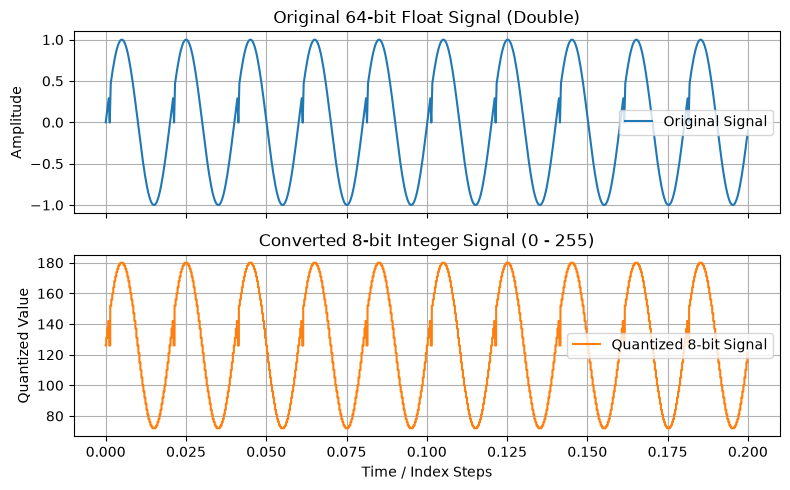

In [8]:
input_sample = 9
float_sample = X_test[input_sample]
int_sample = X_testi[input_sample]

# 4. Print verification metrics
print(f"Original shape: {float_sample.shape} | Dtype: {float_sample.dtype}")
print(f"Converted shape: {int_sample.shape} | Dtype: {int_sample.dtype}")
print(f"Integer Range: Min = {int_sample.min()}, Max = {int_sample.max()}")

# 5. Visualize and compare the signals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
t = np.linspace(0, 0.2, settings['model']['input_shape'][0])

# Plot original continuous signal
ax1.plot(t, float_sample, color="tab:blue", label="Original Signal")
ax1.set_title("Original 64-bit Float Signal (Double)")
ax1.set_ylabel("Amplitude")
ax1.grid(True)
ax1.legend()

# Plot quantized 8-bit integer signal
ax2.step(t, int_sample, color="tab:orange", where="mid", label="Quantized 8-bit Signal")
ax2.set_title("Converted 8-bit Integer Signal (0 - 255)")
ax2.set_xlabel("Time / Index Steps")
ax2.set_ylabel("Quantized Value")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score

In [10]:
accuracy = accuracy_score(Y_test.argmax(axis=1), prediction_classes)
macro_f1 = f1_score(Y_test.argmax(axis=1), prediction_classes, average="macro")
weighted_f1 = f1_score(Y_test.argmax(axis=1), prediction_classes, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    Y_test.argmax(axis=1),
    prediction_classes,
    target_names=metadata['categories']
))

Accuracy: 0.8424
Macro F1-score: 0.8401
Weighted F1-score: 0.8401

Classification Report:
                        precision    recall  f1-score   support

               Flicker       0.96      1.00      0.98        48
     Flicker+Harmonics       1.00      1.00      1.00        48
           Flicker+Sag       0.98      1.00      0.99        48
         Flicker+Swell       1.00      0.94      0.97        48
             Harmonics       0.92      1.00      0.96        48
   Impulsive Transient       0.98      0.90      0.93        48
          Interruption       0.43      0.44      0.43        48
Interruption+Harmonics       0.47      0.33      0.39        48
                Normal       0.84      1.00      0.91        48
                 Notch       0.98      1.00      0.99        48
 Oscillatory transient       1.00      0.98      0.99        48
                   Sag       0.41      0.40      0.40        48
         Sag+Harmonics       0.49      0.60      0.54        48
             